##                                       Medical Insurance Cost Prediction
#### FINAL PROJECT 
#### Dataset: insurance.csv 
#### Roll Number: 3 and 18

## Problem Definition

### Medical insurance companies need to estimate the cost of insurance for individuals.
### The objective of this project is to predict the medical insurance charges of a person based on factors such as age, sex, BMI, number of children, smoking habits, and region.
### Since the target variable (charges) is continuous, Linear Regression is an appropriate model.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



## Dataset Description

#### Features:
#### age        → Age of the person
#### sex        → Gender (male/female)
#### bmi        → Body Mass Index
#### children   → Number of children/dependents
#### smoker     → Whether the person smokes
#### region     → Residential region
#### Target Variable:
#### charges → Medical insurance cost

## Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


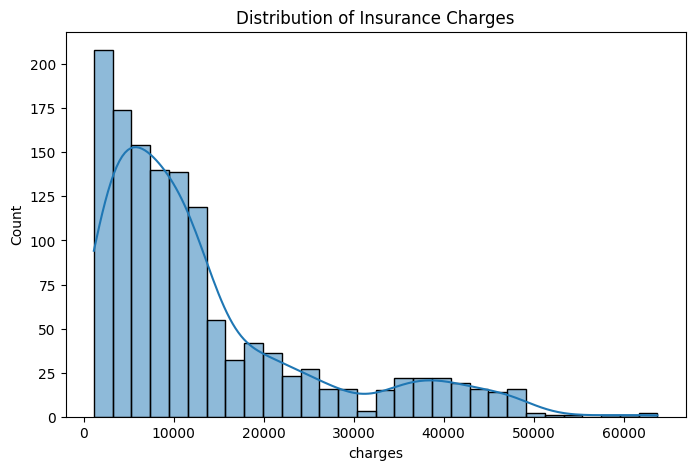

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

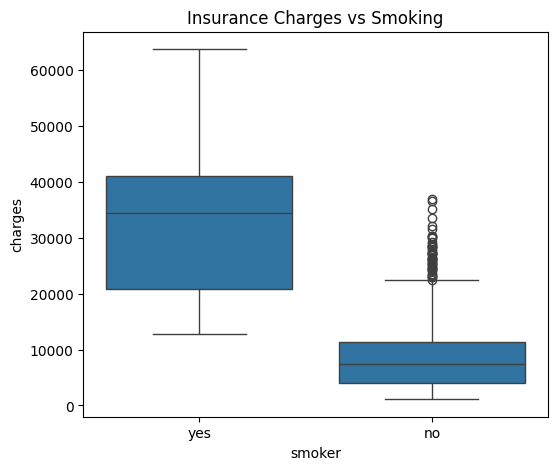

In [7]:
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Insurance Charges vs Smoking")
plt.show()

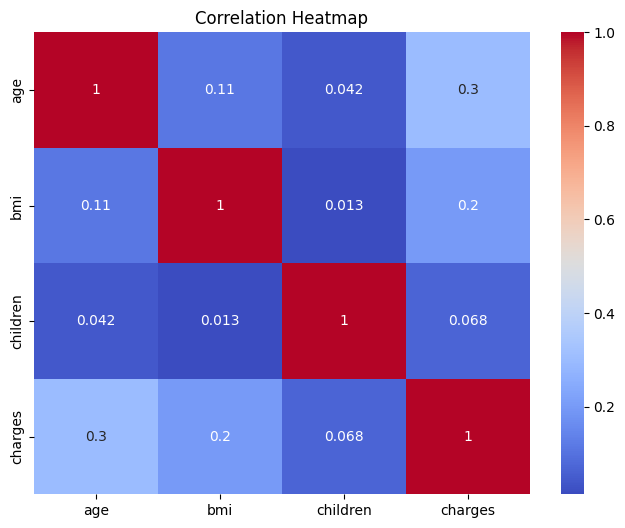

In [8]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [10]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Model Building (Linear Regression)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Evaluation
#### Evaluation Metrics used:
#### - Mean Squared Error (MSE)
#### - Root Mean Squared Error (RMSE)
#### - R² Score

In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 33596915.85136147
Root Mean Squared Error: 5796.2846592762735
R2 Score: 0.7835929767120723


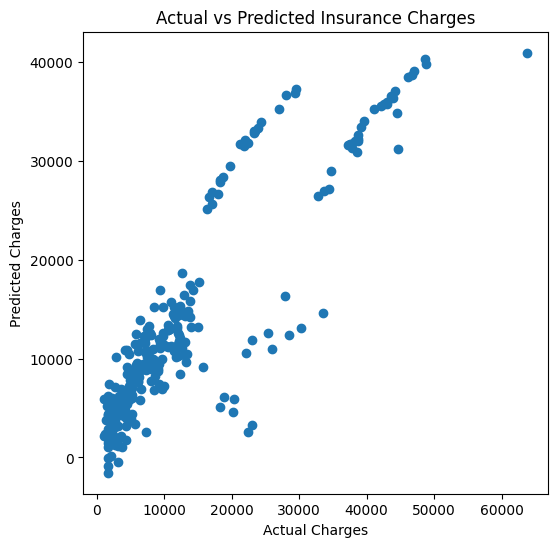

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

## Feature Interpretation

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,smoker_yes,9544.251089
0,age,3609.149018
1,bmi,2054.885063
2,children,512.478869
3,sex_male,-9.295337
5,region_northwest,-158.959435
6,region_southeast,-292.759080
7,region_southwest,-347.270359


## Conclusion
### - Smoking has a strong positive effect on insurance charges.
### - Higher BMI also increases medical insurance costs.
### - Age is positively correlated with insurance charges.
### - The R² score shows how well the model explains variation in insurance cost.
### Linear Regression provides a good baseline model for predicting medical insurance charges.
